# Data Loading and Exploratory Data Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
BASE_PATH   = '/content/drive/MyDrive/NASA_Telemetry_Project/data'
TRAIN_PATH  = os.path.join(BASE_PATH, 'train')
TEST_PATH   = os.path.join(BASE_PATH, 'test')
LABELS_PATH = os.path.join(BASE_PATH, 'labeled_anomalies.csv')

print("Paths set successfully")

Paths set successfully


In [3]:
for split, path in [('TRAIN', TRAIN_PATH), ('TEST', TEST_PATH)]:
    files = os.listdir(path)
    print(f'{split} — {len(files)} files')
    print(f'Sample: {sorted(files)[:5]}\n')

TRAIN — 82 files
Sample: ['A-1.npy', 'A-2.npy', 'A-3.npy', 'A-4.npy', 'A-5.npy']

TEST — 82 files
Sample: ['A-1.npy', 'A-2.npy', 'A-3.npy', 'A-4.npy', 'A-5.npy']



In [4]:
# class column indicates the type of anomaly in each channel
# point      → sudden isolated spike or drop in a single timestep
# contextual → value appears normal alone but abnormal given surrounding context
# XGBoost performs better on point anomalies (captured by min/max/std features)
# contextual anomalies are harder to detect — explains LSTM's lower precision
labels_df = pd.read_csv(LABELS_PATH)
print(f'Shape: {labels_df.shape}')
labels_df.head(10)

Shape: (82, 5)


,chan_id,spacecraft,anomaly_sequences,class,num_values
0,P-1,SMAP,"[[2149, 2349], [4536, 4844], [3539, 3779]]","[contextual, contextual, contextual]",8505
1,S-1,SMAP,"[[5300, 5747]]",[point],7331
2,E-1,SMAP,"[[5000, 5030], [5610, 6086]]","[contextual, contextual]",8516
3,E-2,SMAP,"[[5598, 6995]]",[point],8532
4,E-3,SMAP,"[[5094, 8306]]",[point],8307
5,E-4,SMAP,"[[5450, 8261]]",[point],8354
6,E-5,SMAP,"[[5600, 5920]]",[point],8294
7,E-6,SMAP,"[[5610, 5675]]",[point],8300
8,E-7,SMAP,"[[5394, 5674]]",[point],8310
9,E-8,SMAP,"[[5400, 6022]]",[point],8532


In [5]:
print(labels_df.info())
print('\nSpacecraft distribution:')
print(labels_df['spacecraft'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   chan_id            82 non-null     object
 1   spacecraft         82 non-null     object
 2   anomaly_sequences  82 non-null     object
 3   class              82 non-null     object
 4   num_values         82 non-null     int64 
dtypes: int64(1), object(4)
memory usage: 3.3+ KB
None

Spacecraft distribution:
spacecraft
SMAP    55
MSL     27
Name: count, dtype: int64


In [6]:
sample_name  = 'P-1'
train_sample = np.load(os.path.join(TRAIN_PATH, f'{sample_name}.npy'))
test_sample  = np.load(os.path.join(TEST_PATH,  f'{sample_name}.npy'))

print(f'Train shape : {train_sample.shape}')
print(f'Test shape  : {test_sample.shape}')
print(f'Features    : {train_sample.shape[1]} telemetry channels')

Train shape : (2872, 25)
Test shape  : (8505, 25)
Features    : 25 telemetry channels


In [7]:
def load_all_channels(folder):
    data = {}
    for f in sorted(os.listdir(folder)):
        name = f.replace('.npy', '')
        data[name] = np.load(os.path.join(folder, f))
    return data

train_data = load_all_channels(TRAIN_PATH)
test_data  = load_all_channels(TEST_PATH)

print(f'Train channels loaded : {len(train_data)}')
print(f'Test channels loaded  : {len(test_data)}')

Train channels loaded : 82
Test channels loaded  : 82


In [8]:
shape_info = pd.DataFrame([                          # create a dataframe
    {'Channel': k,                                   # channel name (P-1, S-1 etc)
     'Train_Timesteps': v.shape[0],                  # number of time points
     'Features': v.shape[1]}                         # number of telemetry features
    for k, v in train_data.items()                   # loop through all 82 channels
])
print(shape_info.describe())                         # statistical summary of shapes
shape_info.head(10)                                  # preview first 10 channels

       Train_Timesteps   Features
count        82.000000  82.000000
mean       2399.341463  35.243902
std         832.017453  14.313562
min         312.000000  25.000000
25%        2170.500000  25.000000
50%        2669.000000  25.000000
75%        2880.000000  55.000000
max        4308.000000  55.000000


,Channel,Train_Timesteps,Features
0,A-1,2880,25
1,A-2,2648,25
2,A-3,2736,25
3,A-4,2690,25
4,A-5,705,25
5,A-6,682,25
6,A-7,2879,25
7,A-8,762,25
8,A-9,762,25
9,B-1,2435,25


In [9]:
smap_ids = labels_df[labels_df['spacecraft'] == 'SMAP']['chan_id'].values
msl_ids  = labels_df[labels_df['spacecraft'] == 'MSL']['chan_id'].values

smap_channels = [k for k in train_data.keys() if k in smap_ids]
msl_channels  = [k for k in train_data.keys() if k in msl_ids]

print(f'SMAP channels : {len(smap_channels)}')
print(f'MSL channels  : {len(msl_channels)}')

SMAP channels : 54
MSL channels  : 27


In [10]:
# calculates anomaly % for each channel
# eval() converts anomaly_sequences string to actual list of [start, end] pairs
# end - start + 1 counts total anomaly points in each segment
# anomaly_% reveals class imbalance severity per channel
def compute_anomaly_ratio(labels_df, test_data):
    results = []
    for _, row in labels_df.iterrows():
        chan = row['chan_id']
        if chan not in test_data:
            continue
        total_len      = test_data[chan].shape[0]
        anomaly_seqs   = eval(row['anomaly_sequences'])
        anomaly_points = sum(end - start + 1 for start, end in anomaly_seqs)
        results.append({
            'Channel'       : chan,
            'Spacecraft'    : row['spacecraft'],
            'Total_Points'  : total_len,
            'Anomaly_Points': anomaly_points,
            'Anomaly_%'     : round(anomaly_points / total_len * 100, 2)
        })
    return pd.DataFrame(results)

anomaly_ratio_df = compute_anomaly_ratio(labels_df, test_data)
anomaly_ratio_df.head(10)

,Channel,Spacecraft,Total_Points,Anomaly_Points,Anomaly_%
0,P-1,SMAP,8505,751,8.83
1,S-1,SMAP,7331,448,6.11
2,E-1,SMAP,8516,508,5.97
3,E-2,SMAP,8532,1398,16.39
4,E-3,SMAP,8307,3213,38.68
5,E-4,SMAP,8354,2812,33.66
6,E-5,SMAP,8294,321,3.87
7,E-6,SMAP,8300,66,0.80
8,E-7,SMAP,8310,281,3.38
9,E-8,SMAP,8532,623,7.30


In [11]:
# converts anomaly_sequences into binary label arrays per channel
# np.zeros → all timesteps start as normal (0)
# labels[start:end+1] = 1 → marks anomaly regions as 1
# output → dictionary of {channel_name: binary_array} for all 82 channels
def build_label_arrays(labels_df, test_data):
    label_arrays = {}
    for _, row in labels_df.iterrows():
        chan = row['chan_id']
        if chan not in test_data:
            continue
        labels = np.zeros(test_data[chan].shape[0], dtype=int)
        for start, end in eval(row['anomaly_sequences']):
            labels[start:end+1] = 1
        label_arrays[chan] = labels
    return label_arrays

label_arrays = build_label_arrays(labels_df, test_data)
print(f'Label arrays built: {len(label_arrays)} channels')
print(f'P-1 labels - Normal: {(label_arrays["P-1"]==0).sum()} | Anomaly: {(label_arrays["P-1"]==1).sum()}')

Label arrays built: 81 channels
P-1 labels - Normal: 7754 | Anomaly: 751


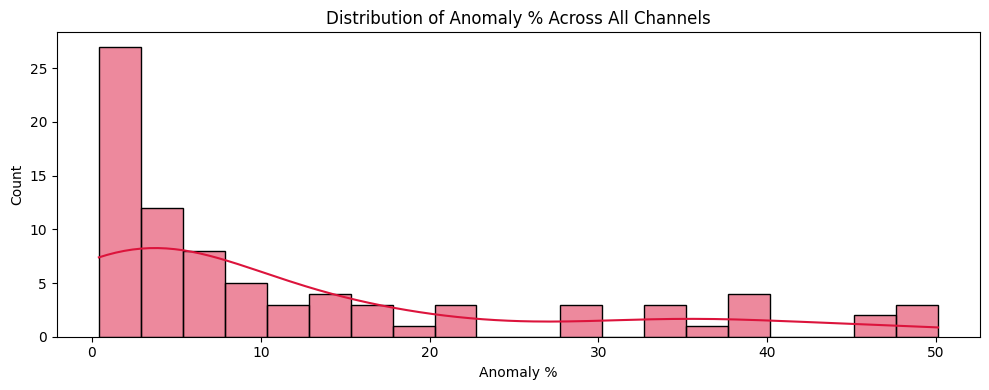

In [12]:
plt.figure(figsize=(10, 4))
sns.histplot(anomaly_ratio_df['Anomaly_%'], bins=20, kde=True, color='crimson')
plt.title('Distribution of Anomaly % Across All Channels')
plt.xlabel('Anomaly %')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

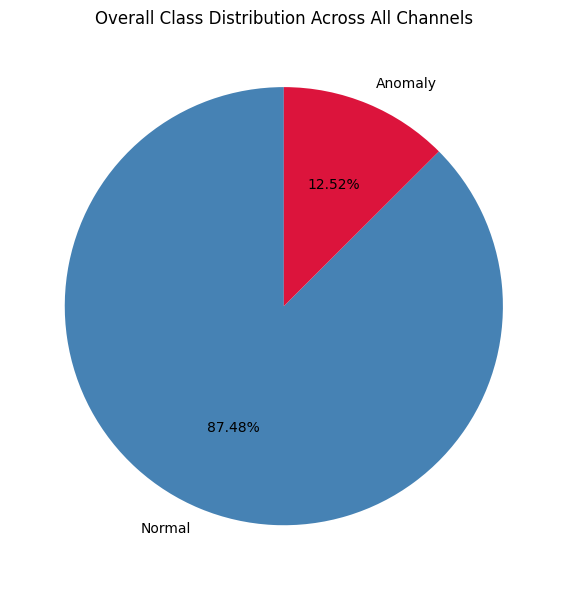

In [13]:
total_normal  = anomaly_ratio_df['Total_Points'].sum() - anomaly_ratio_df['Anomaly_Points'].sum()
total_anomaly = anomaly_ratio_df['Anomaly_Points'].sum()

plt.figure(figsize=(6, 6))
plt.pie(
    [total_normal, total_anomaly],
    labels=['Normal', 'Anomaly'],
    autopct='%1.2f%%',
    colors=['steelblue', 'crimson'],
    startangle=90
)
plt.title('Overall Class Distribution Across All Channels')
plt.tight_layout()
plt.show()

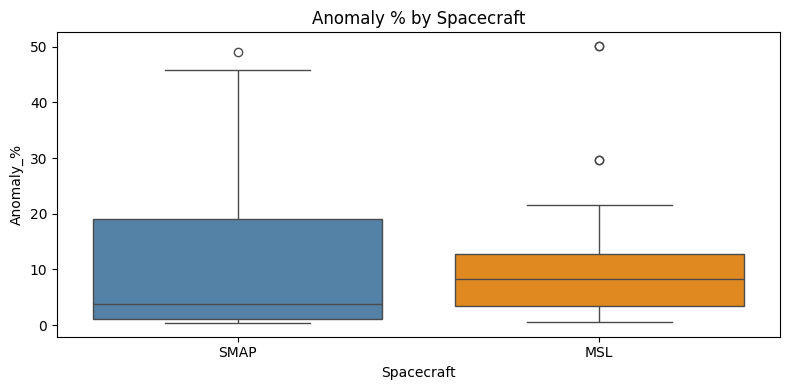

In [14]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=anomaly_ratio_df, x='Spacecraft', y='Anomaly_%',
            palette=['steelblue', 'darkorange'])
plt.title('Anomaly % by Spacecraft')
plt.tight_layout()
plt.show()

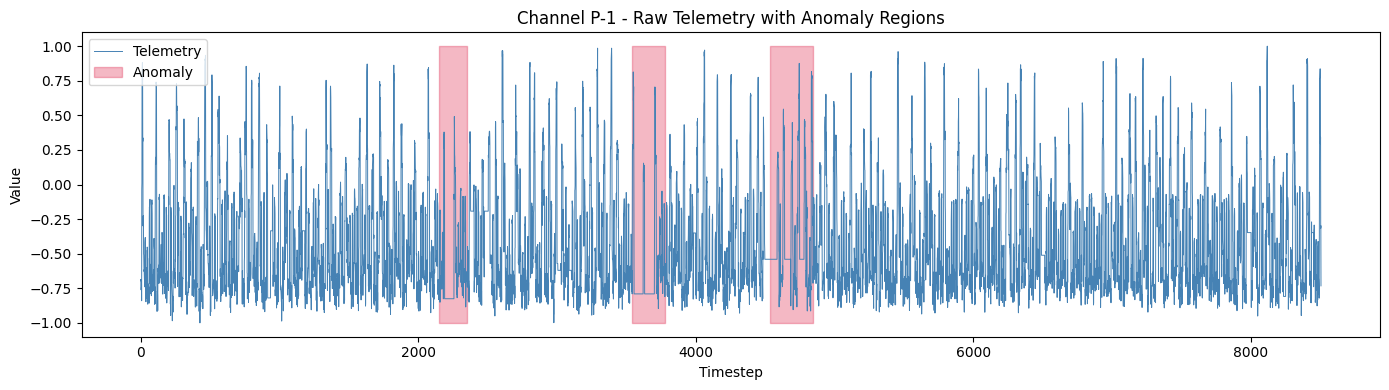

In [15]:
chan   = 'P-1'
signal = test_data[chan][:, 0]
labels = label_arrays[chan]

plt.figure(figsize=(14, 4))
plt.plot(signal, color='steelblue', linewidth=0.7, label='Telemetry')
plt.fill_between(range(len(labels)), signal.min(), signal.max(),
                 where=labels==1, color='crimson', alpha=0.3, label='Anomaly')
plt.title(f'Channel {chan} - Raw Telemetry with Anomaly Regions')
plt.xlabel('Timestep')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()

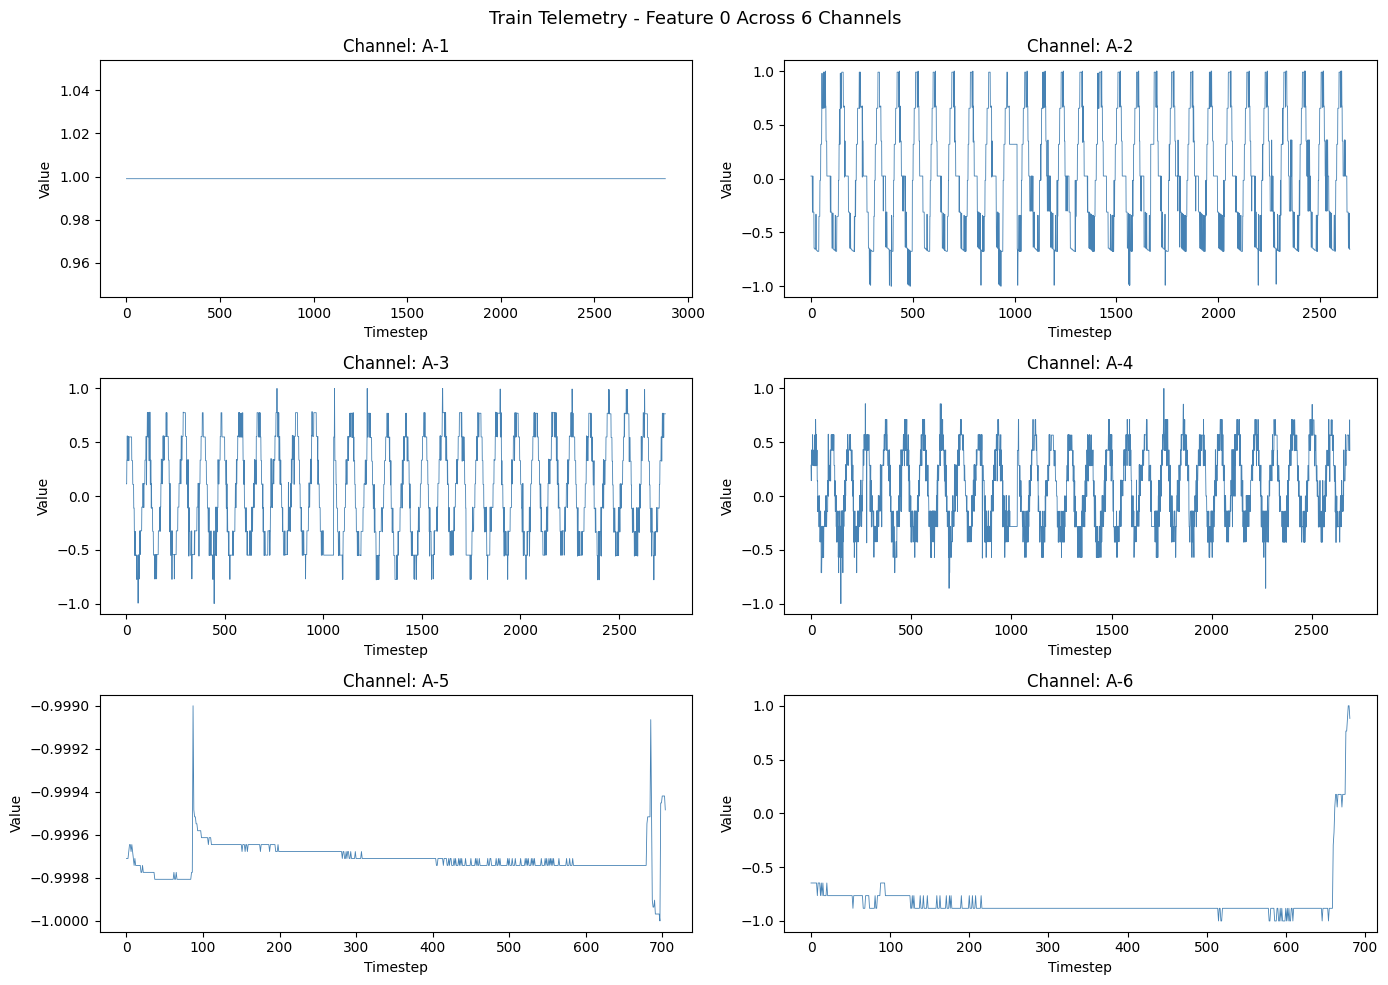

In [16]:
sample_channels = list(train_data.keys())[:6]
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for i, chan in enumerate(sample_channels):
    axes[i].plot(train_data[chan][:, 0], linewidth=0.6, color='steelblue')
    axes[i].set_title(f'Channel: {chan}')
    axes[i].set_xlabel('Timestep')
    axes[i].set_ylabel('Value')

plt.suptitle('Train Telemetry - Feature 0 Across 6 Channels', fontsize=13)
plt.tight_layout()
plt.show()

In [17]:
df_p1 = pd.DataFrame(test_data['P-1'])
df_p1.columns = [f'feature_{i}' for i in range(df_p1.shape[1])]
df_p1['label'] = label_arrays['P-1']
print(f'Shape: {df_p1.shape}')
df_p1.describe().round(4)

Shape: (8505, 26)


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,label
count,8505.0000,8505.0000,8505.0000,8505.0000,8505.0,8505.0000,8505.0000,8505.0000,8505.0000,8505.0000,...,8505.0,8505.0000,8505.0000,8505.0000,8505.0,8505.0000,8505.0000,8505.0,8505.0,8505.0000
mean,-0.4090,0.0368,0.0071,0.0282,0.0,0.1607,0.1253,0.0014,0.0005,0.0007,...,0.0,0.0285,0.0285,0.0142,0.0,0.0423,0.0401,0.0,0.0,0.0883
std,0.4057,0.1883,0.0837,0.1656,0.0,0.3673,0.3311,0.0375,0.0217,0.0266,...,0.0,0.1663,0.1663,0.1184,0.0,0.2013,0.1962,0.0,0.0,0.2837
min,-1.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0,0.0,0.0000
25%,-0.7126,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0,0.0,0.0000
50%,-0.5606,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0,0.0,0.0000
75%,-0.1684,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0,0.0,0.0000
max,1.0000,1.0000,1.0000,1.0000,0.0,1.0000,1.0000,1.0000,1.0000,1.0000,...,0.0,1.0000,1.0000,1.0000,0.0,1.0000,1.0000,0.0,0.0,1.0000


In [18]:
null_counts = df_p1.isnull().sum()
print(f'Total null values: {null_counts.sum()}')
print('No missing data!' if null_counts.sum() == 0 else null_counts[null_counts > 0])

Total null values: 0
No missing data!


In [19]:
skew_kurt = pd.DataFrame({
    'Skewness': df_p1.drop('label', axis=1).skew(),
    'Kurtosis': df_p1.drop('label', axis=1).kurt()
})
print('Top 5 most skewed features:')
skew_kurt.sort_values('Skewness', ascending=False).head()

Top 5 most skewed features:


,Skewness,Kurtosis
feature_8,46.086871,2122.498765
feature_12,46.086871,2122.498765
feature_9,37.616483,1413.332158
feature_13,34.819944,1210.713177
feature_14,34.819944,1210.713177


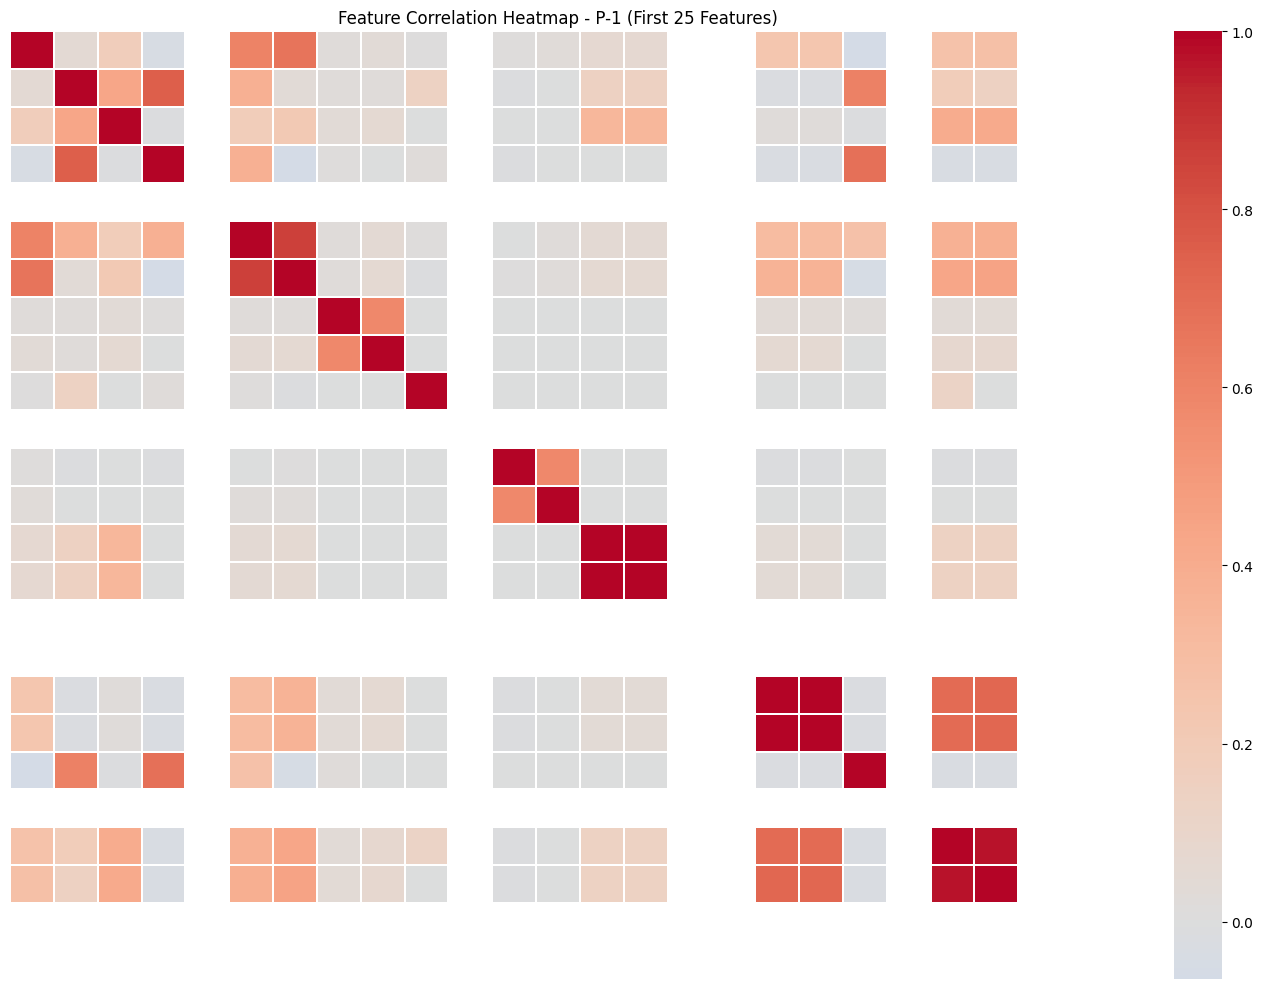

In [20]:
plt.figure(figsize=(14, 10))
corr = df_p1.drop('label', axis=1).iloc[:, :25].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3,
            xticklabels=False, yticklabels=False)
plt.title('Feature Correlation Heatmap - P-1 (First 25 Features)')
plt.tight_layout()
plt.show()

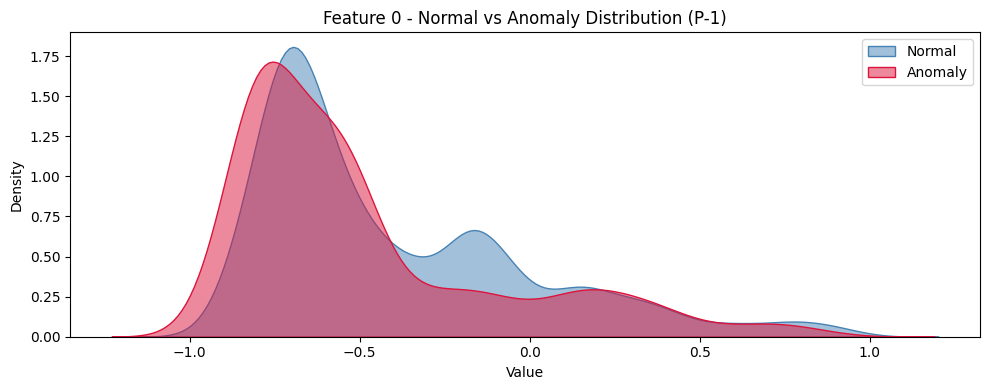

In [21]:
plt.figure(figsize=(10, 4))
sns.kdeplot(df_p1[df_p1['label']==0]['feature_0'], label='Normal',  fill=True, color='steelblue', alpha=0.5)
sns.kdeplot(df_p1[df_p1['label']==1]['feature_0'], label='Anomaly', fill=True, color='crimson',   alpha=0.5)
plt.title('Feature 0 - Normal vs Anomaly Distribution (P-1)')
plt.xlabel('Value')
plt.legend()
plt.tight_layout()
plt.show()

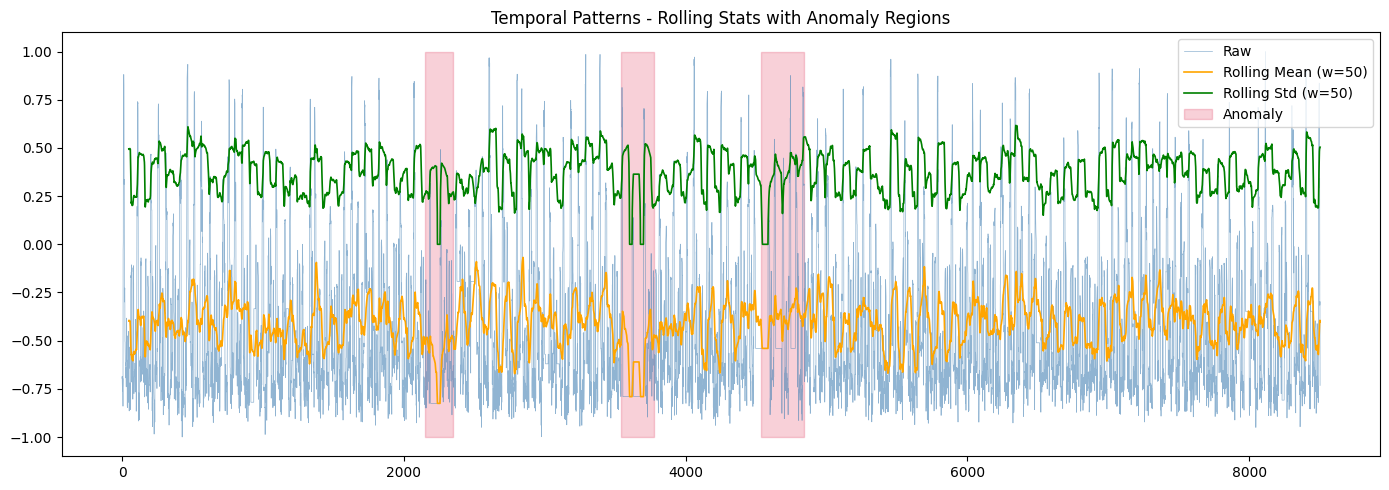

In [22]:
window = 50
signal = df_p1['feature_0']

plt.figure(figsize=(14, 5))
plt.plot(signal,                        color='steelblue', linewidth=0.5, alpha=0.6, label='Raw')
plt.plot(signal.rolling(window).mean(), color='orange',    linewidth=1.2, label=f'Rolling Mean (w={window})')
plt.plot(signal.rolling(window).std(),  color='green',     linewidth=1.2, label=f'Rolling Std (w={window})')
plt.fill_between(range(len(df_p1)), signal.min(), signal.max(),
                 where=df_p1['label']==1, color='crimson', alpha=0.2, label='Anomaly')
plt.title('Temporal Patterns - Rolling Stats with Anomaly Regions')
plt.legend()
plt.tight_layout()
plt.show()

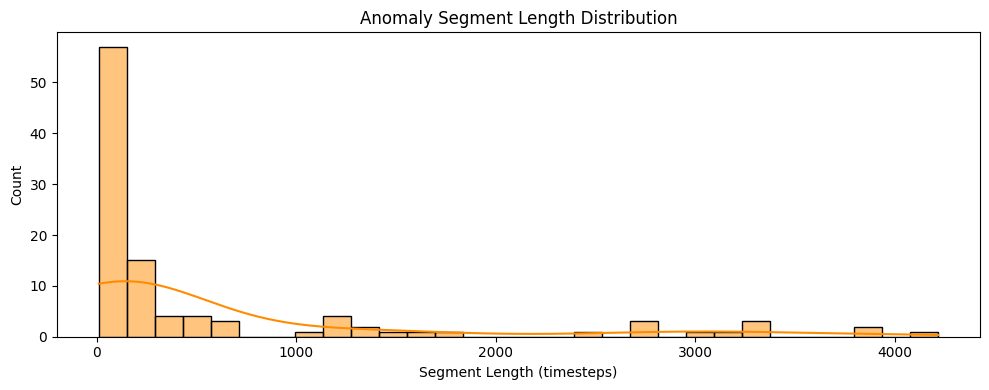

count     105.000000
mean      617.228571
std      1023.944337
min        11.000000
25%        71.000000
50%       121.000000
75%       532.000000
max      4218.000000
dtype: float64


In [23]:
seg_lengths = [
    end - start + 1
    for _, row in labels_df.iterrows()
    for start, end in eval(row['anomaly_sequences'])
]

plt.figure(figsize=(10, 4))
sns.histplot(seg_lengths, bins=30, kde=True, color='darkorange')
plt.title('Anomaly Segment Length Distribution')
plt.xlabel('Segment Length (timesteps)')
plt.tight_layout()
plt.show()

print(pd.Series(seg_lengths).describe())

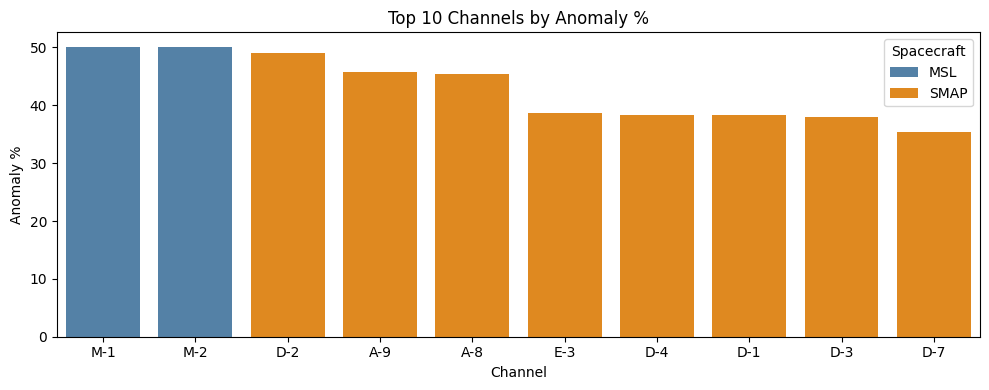

In [24]:
top10 = anomaly_ratio_df.sort_values('Anomaly_%', ascending=False).head(10)

plt.figure(figsize=(10, 4))
sns.barplot(data=top10, x='Channel', y='Anomaly_%',
            hue='Spacecraft', palette=['steelblue', 'darkorange'])
plt.title('Top 10 Channels by Anomaly %')
plt.ylabel('Anomaly %')
plt.tight_layout()
plt.show()

In [25]:
print('=' * 50)
print('EDA SUMMARY REPORT')
print('=' * 50)
print(f'Total channels         : {len(train_data)}')
print(f'SMAP channels          : {len(smap_channels)}')
print(f'MSL channels           : {len(msl_channels)}')
print(f'Avg anomaly %          : {anomaly_ratio_df["Anomaly_%"].mean():.2f}%')
print(f'Max anomaly %          : {anomaly_ratio_df["Anomaly_%"].max():.2f}%')
print(f'Min anomaly %          : {anomaly_ratio_df["Anomaly_%"].min():.2f}%')
print(f'Total anomaly segments : {len(seg_lengths)}')
print(f'Avg segment length     : {pd.Series(seg_lengths).mean():.1f} timesteps')
print(f'Null values (P-1)      : {null_counts.sum()}')
print('=' * 50)
print('Class imbalance confirmed - GAN & SMOTE required in preprocessing phase')

EDA SUMMARY REPORT
Total channels         : 82
SMAP channels          : 54
MSL channels           : 27
Avg anomaly %          : 12.31%
Max anomaly %          : 50.11%
Min anomaly %          : 0.41%
Total anomaly segments : 105
Avg segment length     : 617.2 timesteps
Null values (P-1)      : 0
Class imbalance confirmed - GAN & SMOTE required in preprocessing phase


# Preprocessing

In [26]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_scaled = {}
test_scaled  = {}

for chan in train_data.keys():
    train_scaled[chan] = scaler.fit_transform(train_data[chan])
    test_scaled[chan]  = scaler.transform(test_data[chan])

print(f"Sample P-1 train min: {train_scaled['P-1'].min():.2f}")
print(f"Sample P-1 train max: {train_scaled['P-1'].max():.2f}")

Sample P-1 train min: 0.00
Sample P-1 train max: 1.00


In [27]:
# sliding window converts time-series into supervised learning format
# window_size=128 → each sample contains 128 consecutive timesteps
# step_size=10    → skip 10 timesteps between windows to reduce overlap
# min_features    → trims all channels to 25 features for consistent shape
# train labels = all zeros (no anomaly labels in train data by NASA design)
# test labels  = actual binary labels from label_arrays
def create_windows(data, labels, window_size=128, step=1):
    X, y = [], []
    for i in range(0, len(data) - window_size, step):
        X.append(data[i:i+window_size])
        y.append(labels[i+window_size])
    return np.array(X), np.array(y)

window_size = 128
step_size   = 10

X_train_all, y_train_all = [], []
X_test_all,  y_test_all  = [], []

# find minimum feature size across all channels
min_features = min(train_scaled[chan].shape[1] for chan in train_scaled.keys())
print(f"Min features across channels: {min_features}")

for chan in train_scaled.keys():
    if chan not in label_arrays:
        continue
    X_tr, y_tr = create_windows(train_scaled[chan][:, :min_features], np.zeros(len(train_scaled[chan])), window_size, step_size)
    X_te, y_te = create_windows(test_scaled[chan][:, :min_features],  label_arrays[chan], window_size, step_size)
    X_train_all.append(X_tr)
    y_train_all.append(y_tr)
    X_test_all.append(X_te)
    y_test_all.append(y_te)

X_train = np.concatenate(X_train_all)
y_train = np.concatenate(y_train_all)
X_test  = np.concatenate(X_test_all)
y_test  = np.concatenate(y_test_all)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

Min features across channels: 25
X_train : (18639, 128, 25)
X_test  : (49957, 128, 25)


Class 0 — Count: 43614 | 87.30%
Class 1 — Count: 6343 | 12.70%


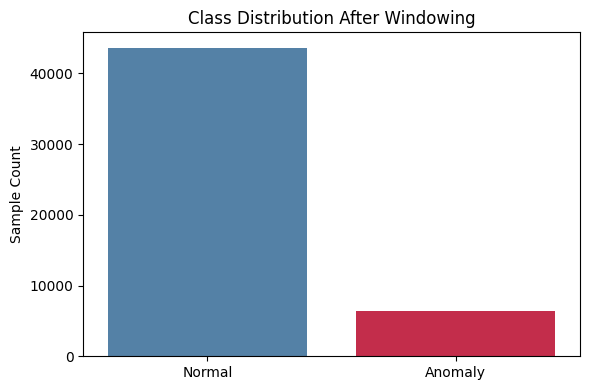

In [28]:
unique, counts = np.unique(y_test, return_counts=True)
total = len(y_test)

for u, c in zip(unique, counts):
    print(f"Class {int(u)} — Count: {c} | {c/total*100:.2f}%")

plt.figure(figsize=(6,4))
sns.barplot(x=['Normal', 'Anomaly'], y=counts, palette=['steelblue', 'crimson'])
plt.title('Class Distribution After Windowing')
plt.ylabel('Sample Count')
plt.tight_layout()
plt.show()

In [29]:
# For Ensemble
def extract_features(X_windows):
    features = []
    for window in X_windows:
        feat = np.concatenate([
            window.mean(axis=0),
            window.std(axis=0),
            window.min(axis=0),
            window.max(axis=0),
            window.max(axis=0) - window.min(axis=0)
        ])
        features.append(feat)
    return np.array(features)

X_train_feat = extract_features(X_train)
X_test_feat  = extract_features(X_test)

print(f"X_train_feat shape : {X_train_feat.shape}")
print(f"X_test_feat shape  : {X_test_feat.shape}")

X_train_feat shape : (18639, 125)
X_test_feat shape  : (49957, 125)


In [30]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_test_feat, y_test)

print(f"Before - Normal: {(y_test==0).sum()} | Anomaly: {(y_test==1).sum()}")
print(f"After  - Normal: {(y_train_balanced==0).sum()} | Anomaly: {(y_train_balanced==1).sum()}")
print(f"X_train_balanced : {X_train_balanced.shape}")

Before - Normal: 43614 | Anomaly: 6343
After  - Normal: 43614 | Anomaly: 43614
X_train_balanced : (87228, 125)


In [31]:
from sklearn.utils import shuffle

X_train_balanced, y_train_balanced = shuffle(X_train_balanced, y_train_balanced, random_state=42)

print("Final Dataset Summary")
print("=" * 40)
print(f"X_train_balanced : {X_train_balanced.shape}")
print(f"y_train_balanced : {y_train_balanced.shape}")
print(f"X_test_feat      : {X_test_feat.shape}")
print(f"y_test           : {y_test.shape}")
print(f"X_train (LSTM)   : {X_train.shape}")
print(f"X_test  (LSTM)   : {X_test.shape}")
print("=" * 40)
print("Preprocessing complete - Ready for modeling")

Final Dataset Summary
X_train_balanced : (87228, 125)
y_train_balanced : (87228,)
X_test_feat      : (49957, 125)
y_test           : (49957,)
X_train (LSTM)   : (18639, 128, 25)
X_test  (LSTM)   : (49957, 128, 25)
Preprocessing complete - Ready for modeling


In [32]:
# LSTM inputs
lstm_X_train = X_train
lstm_X_test  = X_test
lstm_y_test  = y_test

# Ensemble inputs
ens_X_train = X_train_balanced
ens_y_train = y_train_balanced
ens_X_test  = X_test_feat
ens_y_test  = y_test

print("LSTM variables:")
print(f"  lstm_X_train : {lstm_X_train.shape}")
print(f"  lstm_X_test  : {lstm_X_test.shape}")
print(f"  lstm_y_test  : {lstm_y_test.shape}")

print("\nEnsemble variables:")
print(f"  ens_X_train  : {ens_X_train.shape}")
print(f"  ens_y_train  : {ens_y_train.shape}")
print(f"  ens_X_test   : {ens_X_test.shape}")
print(f"  ens_y_test   : {ens_y_test.shape}")

LSTM variables:
  lstm_X_train : (18639, 128, 25)
  lstm_X_test  : (49957, 128, 25)
  lstm_y_test  : (49957,)

Ensemble variables:
  ens_X_train  : (87228, 125)
  ens_y_train  : (87228,)
  ens_X_test   : (49957, 125)
  ens_y_test   : (49957,)


In [33]:
from sklearn.utils import shuffle

# real anomaly windows directly from test
real_anomaly_windows = lstm_X_test[lstm_y_test == 1]
real_anomaly_labels  = np.ones(len(real_anomaly_windows))

# real normal windows from train
real_normal_windows  = lstm_X_train
real_normal_labels   = np.zeros(len(lstm_X_train))

# balance both classes
min_count = min(len(real_anomaly_windows), len(real_normal_windows))

lstm_X_train = np.concatenate([
    real_normal_windows[:min_count],
    real_anomaly_windows[:min_count]
])
lstm_y_train = np.concatenate([
    real_normal_labels[:min_count],
    real_anomaly_labels[:min_count]
])

lstm_X_train, lstm_y_train = shuffle(lstm_X_train, lstm_y_train, random_state=42)

print("LSTM Dataset Summary")
print("=" * 40)
print(f"lstm_X_train : {lstm_X_train.shape}")
print(f"lstm_y_train : {lstm_y_train.shape}")
print(f"Normal       : {(lstm_y_train==0).sum()}")
print(f"Anomaly      : {(lstm_y_train==1).sum()}")
print(f"lstm_X_test  : {lstm_X_test.shape}")
print(f"lstm_y_test  : {lstm_y_test.shape}")
print("=" * 40)
print("LSTM pipeline ready - Real anomaly windows used")

LSTM Dataset Summary
lstm_X_train : (12686, 128, 25)
lstm_y_train : (12686,)
Normal       : 6343
Anomaly      : 6343
lstm_X_test  : (49957, 128, 25)
lstm_y_test  : (49957,)
LSTM pipeline ready - Real anomaly windows used


In [34]:
print("LSTM Pipeline:")
print("=" * 40)
print(f"lstm_X_train : {lstm_X_train.shape}")
print(f"lstm_y_train : {lstm_y_train.shape}")
print(f"lstm_X_test  : {lstm_X_test.shape}")
print(f"lstm_y_test  : {lstm_y_test.shape}")

print("\nEnsemble Pipeline:")
print("=" * 40)
print(f"ens_X_train  : {ens_X_train.shape}")
print(f"ens_y_train  : {ens_y_train.shape}")
print(f"ens_X_test   : {ens_X_test.shape}")
print(f"ens_y_test   : {ens_y_test.shape}")
print("=" * 40)
print("Both pipelines ready - Let's build models!")

LSTM Pipeline:
lstm_X_train : (12686, 128, 25)
lstm_y_train : (12686,)
lstm_X_test  : (49957, 128, 25)
lstm_y_test  : (49957,)

Ensemble Pipeline:
ens_X_train  : (87228, 125)
ens_y_train  : (87228,)
ens_X_test   : (49957, 125)
ens_y_test   : (49957,)
Both pipelines ready - Let's build models!


# Model Building

In [53]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

def focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        loss_1 = -alpha * y_true * tf.math.log(y_pred) * (1 - y_pred) ** gamma
        loss_0 = -(1 - alpha) * (1 - y_true) * tf.math.log(1 - y_pred) * y_pred ** gamma
        return tf.reduce_mean(loss_1 + loss_0)
    return loss

inputs        = layers.Input(shape=(128, 25))
x             = layers.Conv1D(128, kernel_size=3, activation='relu', padding='same')(inputs)
x             = layers.BatchNormalization()(x)
x             = layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=0.3))(x)
attention_out = layers.MultiHeadAttention(num_heads=4, key_dim=128)(x, x)
x             = layers.Add()([x, attention_out])
x             = layers.LayerNormalization()(x)
x             = layers.GlobalAveragePooling1D()(x)
x             = layers.Dense(64, activation='relu')(x)
x             = layers.Dropout(0.4)(x)
outputs       = layers.Dense(1, activation='sigmoid')(x)

model_lstm = models.Model(inputs, outputs)
model_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=focal_loss(),
    metrics=['accuracy']
)
model_lstm.summary()

class_weight_dict = {0: 1, 1: 8}

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model_lstm.fit(
    lstm_X_train, lstm_y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

print("BiLSTM + Attention training complete")

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 25)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 128, 128)  │      9,728 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 128, 256)  │    263,168 │ batch_normalizat… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 128, 256)  │    526,080 │ bidirectional_2[… │
│ (MultiHeadAttentio… │                   │            │ bidirectional_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 128, 256)  │          0 │ bidirectional_2[… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 256)  │        512 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │     16,448 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         65 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 816,513 (3.11 MB)

 Trainable params: 816,257 (3.11 MB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.6355 - loss: 0.3363 - val_accuracy: 0.5823 - val_loss: 0.0620
Epoch 2/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.6628 - loss: 0.2524 - val_accuracy: 0.5662 - val_loss: 0.0603
Epoch 3/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.6900 - loss: 0.2350 - val_accuracy: 0.5469 - val_loss: 0.0675
Epoch 4/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.7031 - loss: 0.2283 - val_accuracy: 0.5662 - val_loss: 0.0584
Epoch 5/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.7292 - loss: 0.2179 - val_accuracy: 0.5666 - val_loss: 0.0574
Epoch 6/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.7391 - loss: 0.2097 - val_accuracy: 0.5800 - val_loss: 0.0548
Epoch 7/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.7626 - loss: 0.2050 - val_accuracy: 0.5875 - val_loss: 0.0586
Epoch 8/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.7789 - loss: 0.2005 - val_acc

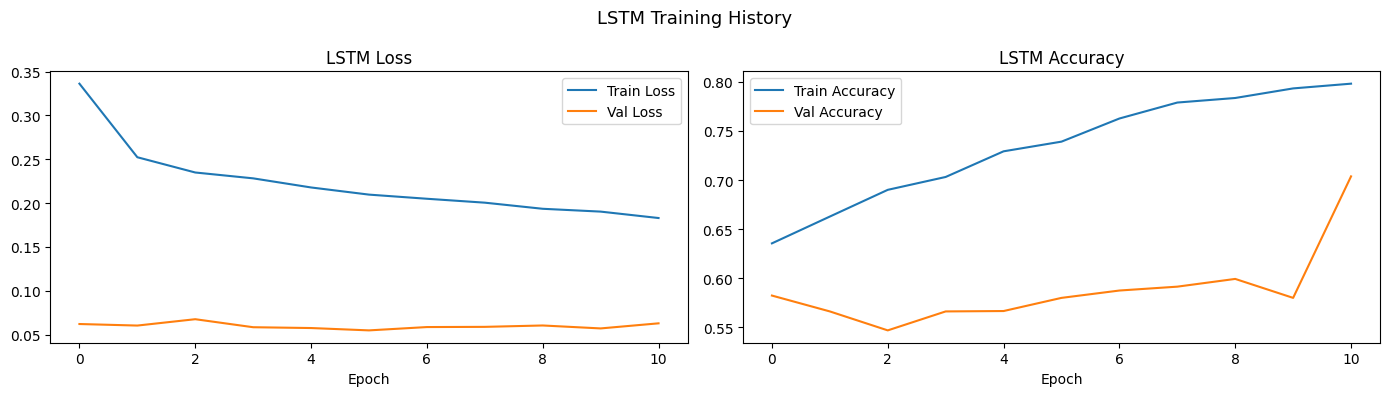

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('LSTM Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('LSTM Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.suptitle('LSTM Training History', fontsize=13)
plt.tight_layout()
plt.show()

In [55]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model_rf.fit(ens_X_train, ens_y_train)
print("Random Forest training complete")

Random Forest training complete


In [56]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=7,
    learning_rate=0.1,
    scale_pos_weight=1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

model_xgb.fit(
    ens_X_train, ens_y_train,
    eval_set=[(ens_X_test, ens_y_test)],
    verbose=50
)

print("XGBoost training complete")

[0]	validation_0-logloss:0.64042
[50]	validation_0-logloss:0.20458
[100]	validation_0-logloss:0.15050
[150]	validation_0-logloss:0.12115
[200]	validation_0-logloss:0.10356
[250]	validation_0-logloss:0.09027
[299]	validation_0-logloss:0.08071
XGBoost training complete


In [57]:
lstm_pred_prob = model_lstm.predict(lstm_X_test, verbose=0)
lstm_pred      = (lstm_pred_prob > 0.4).astype(int).flatten()

rf_pred_prob   = model_rf.predict_proba(ens_X_test)[:, 1]
rf_pred        = model_rf.predict(ens_X_test)

xgb_pred_prob  = model_xgb.predict_proba(ens_X_test)[:, 1]
xgb_pred       = model_xgb.predict(ens_X_test)

print(f"LSTM     - Normal: {(lstm_pred==0).sum()} | Anomaly: {(lstm_pred==1).sum()}")
print(f"RF       - Normal: {(rf_pred==0).sum()}   | Anomaly: {(rf_pred==1).sum()}")
print(f"XGBoost  - Normal: {(xgb_pred==0).sum()}  | Anomaly: {(xgb_pred==1).sum()}")

LSTM     - Normal: 22877 | Anomaly: 27080
RF       - Normal: 36615   | Anomaly: 13342
XGBoost  - Normal: 42889  | Anomaly: 7068


## Hyperparameter Tuning with RandomizedSearchCV

We will now use `RandomizedSearchCV` from scikit-learn to perform hyperparameter tuning for our LSTM, Random Forest, and XGBoost models. This approach samples a fixed number of hyperparameter settings from specified distributions, offering a good balance between exploration and computational cost compared to a full grid search or a potentially very long Optuna run.

In [41]:
!pip install scikit-learn==1.5.1
!pip install scikeras

In [42]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from scikeras.wrappers import KerasClassifier # For Keras/TF models with scikit-learn
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import numpy as np # Needed for parameter distributions

# Focal loss function and class weights
def focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        loss_1 = -alpha * y_true * tf.math.log(y_pred) * (1 - y_pred) ** gamma
        loss_0 = -(1 - alpha) * (1 - y_true) * tf.math.log(1 - y_pred) * y_pred ** gamma
        return tf.reduce_mean(loss_1 + loss_0)
    return loss

class_weight_dict = {0: 1, 1: 8}

print("RandomizedSearchCV, KerasClassifier, other necessary libraries, focal loss, and class weights imported/defined successfully!")

RandomizedSearchCV, KerasClassifier, other necessary libraries, focal loss, and class weights imported/defined successfully!


In [61]:
print('=' * 50)
print('Starting RandomizedSearchCV Hyperparameter Tuning')
print('=' * 50)

# --- LSTM Model Tuning ---
print('\nRunning RandomizedSearchCV for LSTM...')

def create_lstm_model(learning_rate=1e-4, conv_filters=128, lstm_units=128, dropout_rate=0.3):
    inputs = layers.Input(shape=(lstm_X_train.shape[1], lstm_X_train.shape[2]))
    x = layers.Conv1D(conv_filters, kernel_size=3, activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Bidirectional(layers.LSTM(lstm_units, return_sequences=True, dropout=dropout_rate))(x)
    attention_out = layers.MultiHeadAttention(num_heads=4, key_dim=lstm_units)(x, x)
    x = layers.Add()([x, attention_out])
    x = layers.LayerNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate),
        loss=focal_loss(),
        metrics=['accuracy']
    )
    return model

# Define the KerasClassifier wrapper
keras_model = KerasClassifier(
    model=create_lstm_model,
    epochs=10, # Reduced epochs for faster tuning, can be increased later
    batch_size=64, # Default batch size
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, mode='min', restore_best_weights=True)],
    class_weight=class_weight_dict,
    verbose=0 # Suppress verbose output during tuning
)

# Define parameter distributions for RandomizedSearchCV
param_dist_lstm = {
    'model__learning_rate': [1e-5, 5e-5, 1e-4, 5e-4, 1e-3],
    'model__conv_filters': [32, 64, 128, 256],
    'model__lstm_units': [32, 64, 128, 256],
    'model__dropout_rate': [0.2, 0.3, 0.4, 0.5],
    'batch_size': [32, 64, 128]
}

# Using a custom scorer for F1 in RandomizedSearchCV
from sklearn.metrics import make_scorer
f1_scorer = make_scorer(f1_score, greater_is_better=True)

search_lstm = RandomizedSearchCV(
    estimator=keras_model,
    param_distributions=param_dist_lstm,
    n_iter=5, # Number of parameter settings that are sampled. Reduced for faster execution.
    scoring=f1_scorer,
    cv=2, # Number of folds for cross-validation. Reduced for faster execution.
    verbose=1,
    random_state=42,
    n_jobs=-1 # Use all available cores
)

search_lstm.fit(lstm_X_train, lstm_y_train)

print('\nBest parameters for LSTM:')
print(search_lstm.best_params_)
print('Best F1 Score (Cross-validated) for LSTM: {:.4f}'.format(search_lstm.best_score_))
best_lstm_model = search_lstm.best_estimator_

# --- Random Forest Model Tuning ---
print('\nRunning RandomizedSearchCV for Random Forest...')

param_dist_rf = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

model_rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

search_rf = RandomizedSearchCV(
    estimator=model_rf_base,
    param_distributions=param_dist_rf,
    n_iter=10, # More iterations for simpler models
    scoring=f1_scorer,
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search_rf.fit(ens_X_train, ens_y_train)

print('\nBest parameters for Random Forest:')
print(search_rf.best_params_)
print('Best F1 Score (Cross-validated) for Random Forest: {:.4f}'.format(search_rf.best_score_))
best_rf_model = search_rf.best_estimator_

# --- XGBoost Model Tuning ---
print('\nRunning RandomizedSearchCV for XGBoost...')

param_dist_xgb = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
}

model_xgb_base = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

search_xgb = RandomizedSearchCV(
    estimator=model_xgb_base,
    param_distributions=param_dist_xgb,
    n_iter=10, # More iterations
    scoring=f1_scorer,
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search_xgb.fit(ens_X_train, ens_y_train)

print('\nBest parameters for XGBoost:')
print(search_xgb.best_params_)
print('Best F1 Score (Cross-validated) for XGBoost: {:.4f}'.format(search_xgb.best_score_))
best_xgb_model = search_xgb.best_estimator_

print('\nHyperparameter tuning complete for all models.')

# Assign the best models to the original model variable names for subsequent cells
model_lstm = best_lstm_model
model_rf = best_rf_model
model_xgb = best_xgb_model

Starting RandomizedSearchCV Hyperparameter Tuning

Running RandomizedSearchCV for LSTM...
Fitting 2 folds for each of 5 candidates, totalling 10 fits

Best parameters for LSTM:
{'model__lstm_units': 128, 'model__learning_rate': 0.0001, 'model__dropout_rate': 0.3, 'model__conv_filters': 256, 'batch_size': 32}
Best F1 Score (Cross-validated) for LSTM: 0.6689

Running RandomizedSearchCV for Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best parameters for Random Forest:
{'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': None, 'class_weight': None}
Best F1 Score (Cross-validated) for Random Forest: 0.9741

Running RandomizedSearchCV for XGBoost...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best parameters for XGBoost:
{'subsample': 0.7, 'n_estimators': 400, 'max_depth': 7, 'learning_rate': 0.3, 'gamma': 0.0, 'colsample_bytree': 0.6}
Best F1 Score (Cross-validated) for XGBoost: 0.9743

Hyperparameter tuning 

In [63]:
import joblib

model_lstm.model_.save('/content/drive/MyDrive/NASA_Telemetry_Project/model_lstm.keras')
joblib.dump(model_rf,  '/content/drive/MyDrive/NASA_Telemetry_Project/model_rf.joblib')
joblib.dump(model_xgb, '/content/drive/MyDrive/NASA_Telemetry_Project/model_xgb.joblib')

print("All models saved to Drive ✅")

All models saved to Drive ✅


# Evaluation

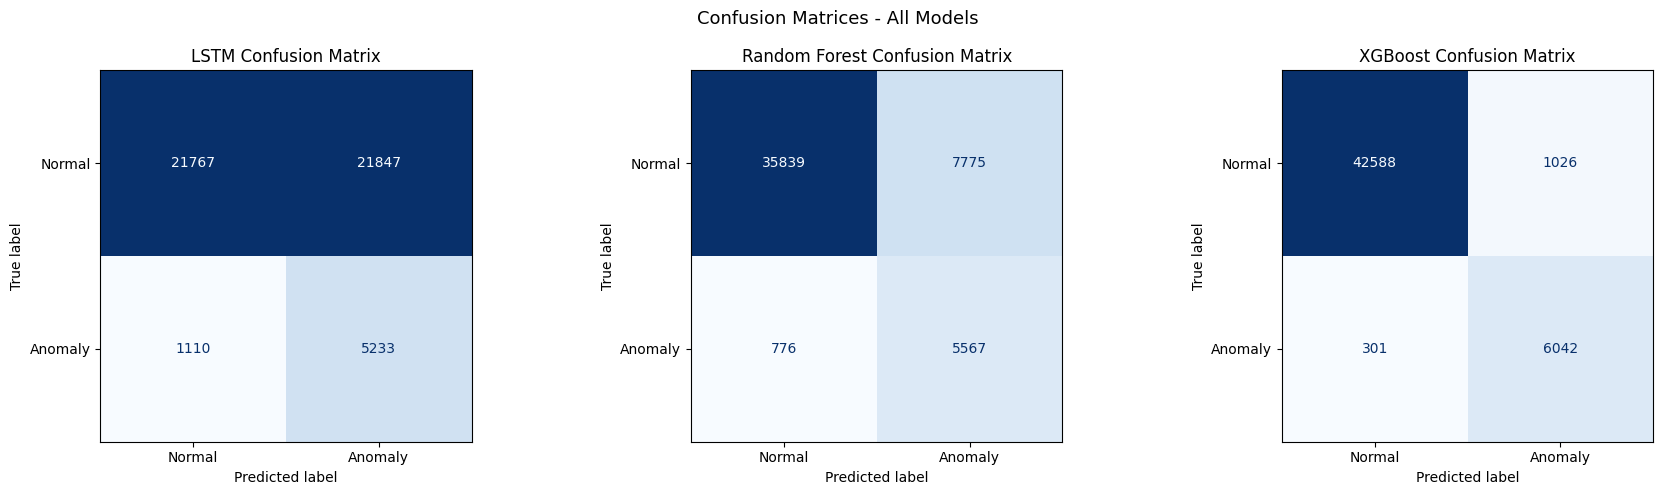

In [64]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_info = [
    ('LSTM',    lstm_y_test, lstm_pred),
    ('Random Forest', ens_y_test, rf_pred),
    ('XGBoost', ens_y_test, xgb_pred)
]

for ax, (name, y_true, y_pred) in zip(axes, models_info):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Anomaly'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name} Confusion Matrix')

plt.suptitle('Confusion Matrices - All Models', fontsize=13)
plt.tight_layout()
plt.show()

In [65]:
from sklearn.metrics import classification_report

for name, y_true, y_pred in models_info:
    print(f"{'='*45}")
    print(f" {name}")
    print(f"{'='*45}")
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomaly']))

 LSTM
              precision    recall  f1-score   support

      Normal       0.95      0.50      0.65     43614
     Anomaly       0.19      0.83      0.31      6343

    accuracy                           0.54     49957
   macro avg       0.57      0.66      0.48     49957
weighted avg       0.86      0.54      0.61     49957

 Random Forest
              precision    recall  f1-score   support

      Normal       0.98      0.82      0.89     43614
     Anomaly       0.42      0.88      0.57      6343

    accuracy                           0.83     49957
   macro avg       0.70      0.85      0.73     49957
weighted avg       0.91      0.83      0.85     49957

 XGBoost
              precision    recall  f1-score   support

      Normal       0.99      0.98      0.98     43614
     Anomaly       0.85      0.95      0.90      6343

    accuracy                           0.97     49957
   macro avg       0.92      0.96      0.94     49957
weighted avg       0.98      0.97      0.97 

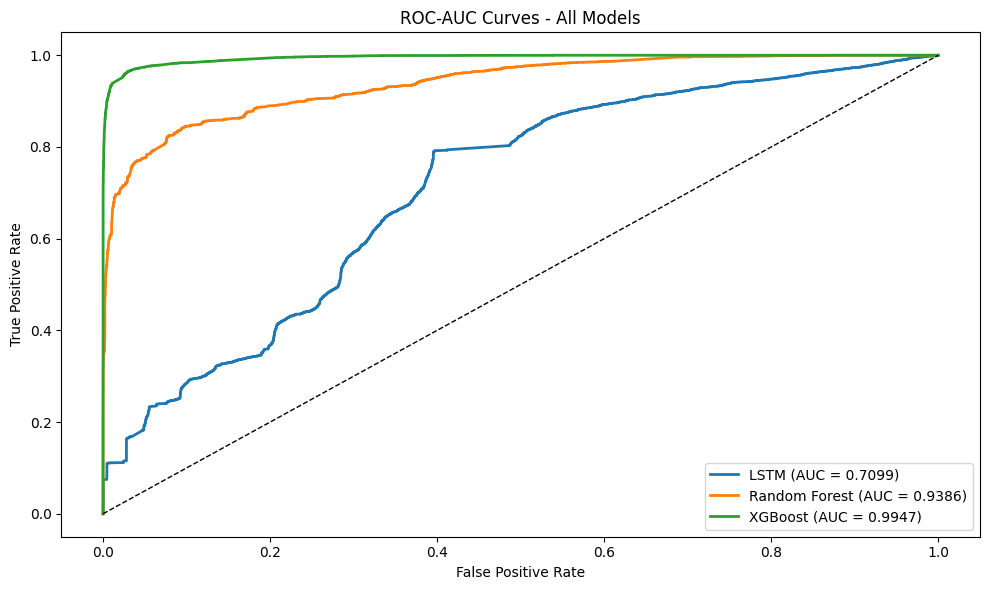

In [66]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 6))

roc_info = [
    ('LSTM',          lstm_y_test, lstm_pred_prob.flatten()),
    ('Random Forest', ens_y_test,  rf_pred_prob),
    ('XGBoost',       ens_y_test,  xgb_pred_prob)
]

for name, y_true, y_prob in roc_info:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0,1], [0,1], 'k--', linewidth=1)
plt.title('ROC-AUC Curves - All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

In [67]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, accuracy_score

results = []
for name, y_true, y_pred, y_prob in [
    ('LSTM',          lstm_y_test, lstm_pred,  lstm_pred_prob.flatten()),
    ('Random Forest', ens_y_test,  rf_pred,    rf_pred_prob),
    ('XGBoost',       ens_y_test,  xgb_pred,   xgb_pred_prob)
]:
    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred) * 100, 2),
        'Precision': round(precision_score(y_true, y_pred) * 100, 2),
        'Recall'   : round(recall_score(y_true, y_pred) * 100, 2),
        'F1 Score' : round(f1_score(y_true, y_pred) * 100, 2),
        'ROC-AUC'  : round(roc_auc_score(y_true, y_prob) * 100, 2)
    })

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.to_string())

               Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                        
LSTM              54.05      19.32   82.50     31.31    70.99
Random Forest     82.88      41.73   87.77     56.56    93.86
XGBoost           97.34      85.48   95.25     90.11    99.47


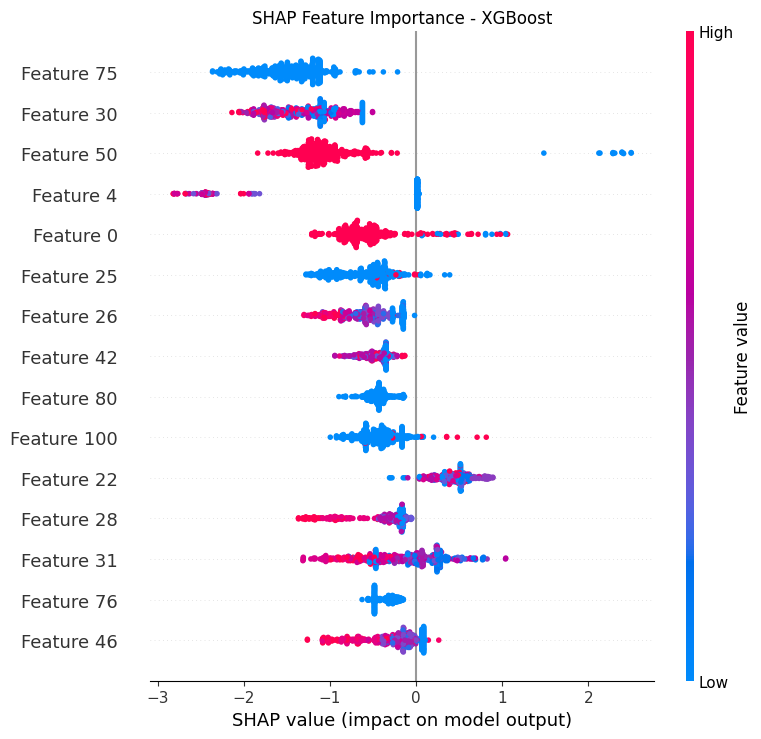

In [48]:
import shap

explainer   = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(ens_X_test[:500])

plt.figure()
shap.summary_plot(shap_values, ens_X_test[:500], max_display=15, show=False)
plt.title('SHAP Feature Importance - XGBoost')
plt.tight_layout()
plt.show()

# Predictive System

In [49]:
from sklearn.preprocessing import MinMaxScaler

# take a sample channel
test_channel = 'P-1'
X_sample     = test_data[test_channel]
y_sample     = label_arrays[test_channel]

# scale
scaler_sample   = MinMaxScaler()
X_sample_scaled = scaler_sample.fit_transform(X_sample)
X_sample_scaled = X_sample_scaled[:, :25]

# create windows
X_win, y_win = create_windows(X_sample_scaled, y_sample, window_size=128, step=10)
print(f"Windows created : {X_win.shape}")

# extract flat features for ensemble
X_win_feat = extract_features(X_win)

# LSTM prediction
lstm_sample_prob = model_lstm.predict(X_win, verbose=0)
lstm_sample_pred = (lstm_sample_prob > 0.4).astype(int).flatten()

# RF prediction
rf_sample_pred  = model_rf.predict(X_win_feat)

# XGBoost prediction
xgb_sample_pred = model_xgb.predict(X_win_feat)

print(f"\nGround Truth  - Normal: {(y_win==0).sum()} | Anomaly: {(y_win==1).sum()}")
print(f"LSTM          - Normal: {(lstm_sample_pred==0).sum()} | Anomaly: {(lstm_sample_pred==1).sum()}")
print(f"Random Forest - Normal: {(rf_sample_pred==0).sum()} | Anomaly: {(rf_sample_pred==1).sum()}")
print(f"XGBoost       - Normal: {(xgb_sample_pred==0).sum()} | Anomaly: {(xgb_sample_pred==1).sum()}")

Windows created : (838, 128, 25)

Ground Truth  - Normal: 763 | Anomaly: 75
LSTM          - Normal: 836 | Anomaly: 2
Random Forest - Normal: 783 | Anomaly: 55
XGBoost       - Normal: 758 | Anomaly: 80


In [68]:
# save scaler and config
joblib.dump(scaler, '/content/drive/MyDrive/NASA_Telemetry_Project/scaler.joblib')
np.save('/content/drive/MyDrive/NASA_Telemetry_Project/min_features.npy', np.array([25]))

print("All files saved ✅")

All files saved ✅
